# Oráculo: índices de calidad (SQI, CCOR, SIG)

Oráculo de `docs/algorithms/indices-de-calidad.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio"). Los tres
índices se derivan de cantidades que el pulse-pair ya calcula, así que este
notebook reutiliza el generador de I/Q y la cadena de ruido sin cambios
respecto a los oráculos anteriores, y añade sólo lo propio de esta página.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260906)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def generate_pure_tone_cell(power_s, bin_index, wavelength_m, prt_s, m, rng, noise_floor=0.0):
    """Blanco puntual/tono puro exacto: toda la potencia en un único bin
    Doppler discreto (delta de Kronecker), no una gaussiana con sigma_v
    diminuto — eso subdesborda a 0/0 en punto flotante antes de llegar a ser
    'un tono'."""
    spectrum = np.zeros(m)
    spectrum[bin_index] = power_s
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram(y)) * len(y)


def r0_r1(y):
    r0 = np.mean(np.abs(y) ** 2)
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return r0, r1


checks = []

## SQI

`SQI = |R̂(1)| / R̂(0)`, calculado sobre la serie que se usó para estimar la
velocidad (sin resta de ruido — así lo define la página). El modelo cerrado
gaussiano ya usado y validado en el oráculo del simulador de I/Q da
`|R(T)|/R(0)_señal = exp(-8π²σv²T²/λ²) = ρ(T)`; con ruido aditivo de potencia
`N`, `R̂(0)` incluye `N` pero `R̂(1)` no se ve sesgado por él (ruido blanco
incoherente entre pulsos), así que el SQI esperado a SNR finita es
`ρ(T)·SNR/(SNR+1)` — se deriva aquí, no se copia de ningún sitio.

Los dos casos límite de la página tienen, además, forma cerrada propia:

- **Ruido puro** (`SNR=0`, sin señal): `R̂(1)` es la media de `M-1` productos
  de ruido blanco complejo independiente, asintóticamente gaussiano complejo
  por CLT con varianza `≈ N²/(M-1)`; su módulo es Rayleigh, y
  `E[SQI] ≈ √π / (2√(M-1))` — se deriva aquí y se comprueba numéricamente,
  no es una cita de la literatura.
- **Tono puro** (blanco puntual, toda la potencia en un único bin Doppler):
  `SQI = 1` exactamente, salvo precisión de punto flotante.

 SNR   sv   rho(T)  SQI esperado  SQI medido
   0  0.5   0.9980        0.4990      0.4701
   0  1.5   0.9824        0.4912      0.4788


   0  3.0   0.9314        0.4657      0.4666
  10  0.5   0.9980        0.9073      0.8714
  10  1.5   0.9824        0.8931      0.8794


  10  3.0   0.9314        0.8467      0.8418
  20  0.5   0.9980        0.9881      0.9826
  20  1.5   0.9824        0.9727      0.9715


  20  3.0   0.9314        0.9222      0.9218
  40  0.5   0.9980        0.9979      0.9980
  40  1.5   0.9824        0.9823      0.9818
  40  3.0   0.9314        0.9313      0.9318



SQI ruido puro: medido=0.1120  predicho (Rayleigh, derivado arriba)=0.1117
SQI tono puro: medido=1.000000  (esperado 1.0 exacto)


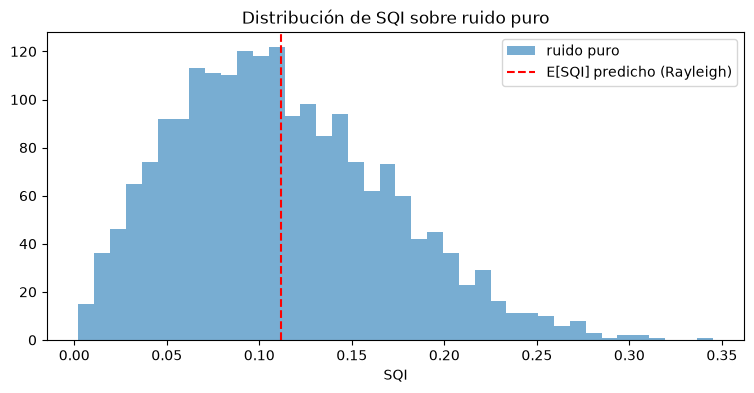

In [3]:
WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
MEAN_V = 5.0

SQI_ABS_TOLERANCE = 0.08  # generoso: sesgo de muestra finita conocido del cociente |R1|/R0


def sqi_of(y):
    r0, r1 = r0_r1(y)
    return np.abs(r1) / r0


SNR_DB_GRID = [0, 10, 20, 40]
SIGMA_V_GRID = [0.5, 1.5, 3.0]
M = 64
NOISE_FLOOR = 0.05
N_TRIALS_SQI = 600

sqi_ok = True
print(f"{'SNR':>4} {'sv':>4} {'rho(T)':>8} {'SQI esperado':>13} {'SQI medido':>11}")
for snr_db in SNR_DB_GRID:
    power_s = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    snr_lin = power_s / NOISE_FLOOR
    for sigma_v in SIGMA_V_GRID:
        rho_t = np.exp(-8.0 * np.pi ** 2 * sigma_v ** 2 * PRT_S ** 2 / WAVELENGTH_M ** 2)
        expected = rho_t * snr_lin / (snr_lin + 1.0)
        measured = np.mean([
            sqi_of(generate_cell(power_s, MEAN_V, sigma_v, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng))
            for _ in range(N_TRIALS_SQI)
        ])
        print(f"{snr_db:4d} {sigma_v:4.1f} {rho_t:8.4f} {expected:13.4f} {measured:11.4f}")
        if abs(measured - expected) >= SQI_ABS_TOLERANCE:
            sqi_ok = False

checks.append((f"SQI medido sigue ρ(T)·SNR/(SNR+1) dentro de {SQI_ABS_TOLERANCE} en toda la malla", sqi_ok))

# extremos
N_EXTREME = 2000
pure_noise_sqi = np.array([
    sqi_of(generate_cell(0.0, 0.0, 1.0, WAVELENGTH_M, PRT_S, M, 1.0, rng)) for _ in range(N_EXTREME)
])
expected_noise_sqi = np.sqrt(np.pi) / (2.0 * np.sqrt(M - 1))
print(f"\nSQI ruido puro: medido={pure_noise_sqi.mean():.4f}  "
      f"predicho (Rayleigh, derivado arriba)={expected_noise_sqi:.4f}")
checks.append(("SQI sobre ruido puro converge a la predicción de Rayleigh dentro de 15%",
               abs(pure_noise_sqi.mean() - expected_noise_sqi) < 0.15 * expected_noise_sqi))

pure_tone_sqi = np.array([
    sqi_of(generate_pure_tone_cell(1.0, 10, WAVELENGTH_M, PRT_S, M, rng)) for _ in range(200)
])
print(f"SQI tono puro: medido={pure_tone_sqi.mean():.6f}  (esperado 1.0 exacto)")
checks.append(("SQI sobre tono puro es 1.0 salvo precisión de punto flotante (< 1e-9)",
               np.max(np.abs(pure_tone_sqi - 1.0)) < 1e-9))

fig, ax = plt.subplots()
ax.hist(pure_noise_sqi, bins=40, alpha=0.6, label="ruido puro")
ax.axvline(expected_noise_sqi, color="red", linestyle="--", label="E[SQI] predicho (Rayleigh)")
ax.set_xlabel("SQI"); ax.set_title("Distribución de SQI sobre ruido puro"); ax.legend()
plt.show()

## CCOR

`CCOR = 10·log10(P_filtrada / P_total)`. Como no hay todavía ningún filtro de
clutter implementado (GMAP es una página propia, fase 2), este oráculo no lo
sustituye: inyecta un espectro con clutter estacionario de potencia
**exactamente conocida** en el bin de velocidad cero y aplica un notch ideal
—quitar ese bin exacto en el dominio espectral— sólo como generador de un
`(P_total, P_filtrada)` con razón analíticamente conocida, para comprobar que
la contabilidad de potencias y la conversión a dB son correctas. Esto no
valida ningún algoritmo de filtrado real; valida la fórmula de CCOR.

In [4]:
POWER_S = 1.0
CLUTTER_POWER = 50.0
SIGMA_V_CCOR = 1.5
N_TRIALS_CCOR = 4000
CCOR_TOLERANCE_DB = 0.5


def total_and_filtered_power(rng):
    spectrum = gaussian_doppler_spectrum(POWER_S, MEAN_V, SIGMA_V_CCOR, WAVELENGTH_M, PRT_S, M)
    spectrum[0] += CLUTTER_POWER  # bin de velocidad cero: blanco estacionario
    w = complex_gaussian(rng, 1.0, size=M)
    shaped = w * np.sqrt(spectrum)
    y_total = np.fft.ifft(shaped) * M
    y_spec = np.fft.fft(y_total)
    y_spec[0] = 0.0  # notch ideal: quita exactamente el bin de clutter
    y_filtered = np.fft.ifft(y_spec)
    return np.mean(np.abs(y_total) ** 2), np.mean(np.abs(y_filtered) ** 2)


totals, filtereds = zip(*(total_and_filtered_power(rng) for _ in range(N_TRIALS_CCOR)))
p_total_mean, p_filtered_mean = np.mean(totals), np.mean(filtereds)
ccor_measured = 10.0 * np.log10(p_filtered_mean / p_total_mean)

spectrum_clean = gaussian_doppler_spectrum(POWER_S, MEAN_V, SIGMA_V_CCOR, WAVELENGTH_M, PRT_S, M)
bin0_power = spectrum_clean[0] + CLUTTER_POWER
total_power_expected = POWER_S + CLUTTER_POWER
filtered_power_expected = total_power_expected - bin0_power
ccor_expected = 10.0 * np.log10(filtered_power_expected / total_power_expected)

print(f"P_total medido={p_total_mean:.4f} (esperado {total_power_expected:.4f})")
print(f"P_filtrada medido={p_filtered_mean:.4f} (esperado {filtered_power_expected:.4f})")
print(f"CCOR medido={ccor_measured:.3f} dB  esperado={ccor_expected:.3f} dB")
checks.append((f"CCOR reproduce la razón de potencias conocida dentro de {CCOR_TOLERANCE_DB} dB",
               abs(ccor_measured - ccor_expected) < CCOR_TOLERANCE_DB))
checks.append(("CCOR es 0 dB cuando el filtro está inactivo (P_filtrada == P_total)",
               abs(10.0 * np.log10(p_total_mean / p_total_mean)) < 1e-9))

P_total medido=49.8290 (esperado 51.0000)
P_filtrada medido=0.9977 (esperado 0.9992)
CCOR medido=-16.985 dB  esperado=-17.079 dB


## SIG

`SIG = 10·log10((R(0) − N) / N)`, recortada a la censura de
`ruido-y-umbrales.md`. Ya se validó ahí la resta de ruido y su sesgo
conocido; aquí sólo se confirma que la conversión a dB de esa misma cantidad
—lo único propio de esta página— es correcta.

In [5]:
NOISE_FLOOR_SIG = 0.05
SNR_DB_TEST = [5.0, 10.0, 20.0]
N_TRIALS_SIG = 2000
SIG_BIAS_TOLERANCE_DB = 2.0  # N-hat aparece en numerador y denominador: el sesgo
# conocido de HS74 (oráculo de ruido-y-umbrales.md, ~0.4 dB con navg=1) se
# compone en vez de cancelarse, así que el sesgo de SIG es mayor que el de Z solo

sig_ok = True
for snr_db in SNR_DB_TEST:
    power_s = NOISE_FLOOR_SIG * 10.0 ** (snr_db / 10.0)
    sig_estimates = []
    for _ in range(N_TRIALS_SIG):
        y = generate_cell(power_s, MEAN_V, 1.5, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR_SIG, rng)
        r0 = np.mean(np.abs(y) ** 2)
        n_hat = noise_floor_estimate(y)
        s_hat = max(r0 - n_hat, 0.0)
        if s_hat > 0.0:
            sig_estimates.append(10.0 * np.log10(s_hat / n_hat))
    sig_mean = np.mean(sig_estimates)
    print(f"SNR={snr_db:5.1f} dB  SIG medio={sig_mean:.3f} dB  "
          f"(N usado = N̂, no el inyectado — sesgo esperado por N̂ ya caracterizado)")
    if abs(sig_mean - snr_db) >= SIG_BIAS_TOLERANCE_DB:
        sig_ok = False

checks.append((f"SIG sigue la SNR inyectada dentro de {SIG_BIAS_TOLERANCE_DB} dB para SNR>=5 dB", sig_ok))

SNR=  5.0 dB  SIG medio=6.271 dB  (N usado = N̂, no el inyectado — sesgo esperado por N̂ ya caracterizado)


SNR= 10.0 dB  SIG medio=11.491 dB  (N usado = N̂, no el inyectado — sesgo esperado por N̂ ya caracterizado)


SNR= 20.0 dB  SIG medio=21.177 dB  (N usado = N̂, no el inyectado — sesgo esperado por N̂ ya caracterizado)


In [6]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de índices de calidad no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] SQI medido sigue ρ(T)·SNR/(SNR+1) dentro de 0.08 en toda la malla
[OK] SQI sobre ruido puro converge a la predicción de Rayleigh dentro de 15%
[OK] SQI sobre tono puro es 1.0 salvo precisión de punto flotante (< 1e-9)
[OK] CCOR reproduce la razón de potencias conocida dentro de 0.5 dB
[OK] CCOR es 0 dB cuando el filtro está inactivo (P_filtrada == P_total)
[OK] SIG sigue la SNR inyectada dentro de 2.0 dB para SNR>=5 dB

Todas las comprobaciones dentro de tolerancia.
